In [1]:
import os
import time
import json
import pandas as pd
from tqdm import tqdm
from openai import OpenAI

In [2]:
#import httpx

from pathlib import Path
from dotenv import load_dotenv
import os

env_path = Path.cwd().parent / ".env"
load_dotenv(env_path)

API_KEY = os.getenv("OPENAI_API_KEY")

if not API_KEY:
    raise ValueError("OPENAI_API_KEY 로드 실패")

client = OpenAI(
    api_key=API_KEY
    # http_client=httpx.Client(verify=False, timeout=120), 내부망일경우 SSL 인증 문제로 인해 추가 설정 필요
)  # OPENAI_API_KEY 환경변수에 세팅되어 있어야 함
MODEL_NAME = "gpt-4.1-mini"  # 필요시 변경


In [3]:
DATA_DIR = str(Path.cwd().parent / "데이터수집" / "data")
print("기준 폴더:", DATA_DIR)

In [4]:
SYSTEM_PROMPT_MEETING = """
너는 국회 회의록을 분석하는 전문가다.
한 회차의 전체 발언 내용을 바탕으로 회의의 핵심을 정리한다.
"""


In [5]:
def build_meeting_prompt(meeting_round: str, speeches: str) -> str:
    return f"""
다음은 {meeting_round} 국회 회의에서 나온 전체 발언 내용이다.

\"\"\"
{speeches}
\"\"\"

위 회의 내용을 종합·분석하여
반드시 아래 형식의 JSON만 출력하라.

형식:
{{
  "major_agenda": [
    "주요 안건 1",
    "주요 안건 2",
    "주요 안건 3"
  ],
  "meeting_summary": "회의 전체 핵심 내용을 약 10줄 이내로 요약",
  "keywords": [
    {{
      "keyword": "키워드1",
      "weight": 10,
      "reason": "회의 전반에서 가장 핵심적으로 반복 언급된 주제"
    }},
    {{
      "keyword": "키워드2",
      "weight": 7,
      "reason": "주요 안건과 직접적으로 연관된 핵심 개념"
    }}
  ]
}}

키워드 추출 규칙:
- keywords는 5~10개
- keyword는 워드클라우드에 쓰기 적합한 명사/이슈 단위
- weight는 중요도를 나타내는 정수 (1~10)
  · 10: 회의의 핵심 주제
  · 7~9: 주요 쟁점·안건
  · 4~6: 반복 언급된 보조 개념
  · 1~3: 맥락상 언급된 부수 개념
- reason은 왜 중요한지 한 줄로 설명
- 키워드는 #을 붙이지 말 것 (시각화용 가공을 위해)

공통 규칙:
- major_agenda: 3~5개
- meeting_summary: 10줄 이내
- JSON 외의 설명은 절대 출력하지 마라.
"""


In [6]:
def summarize_meeting(meeting_round: str, speeches: str,
                      model="gpt-4.1-mini", max_chars=12000):
    """
    회차 전체 발언을 받아
    - major_agenda
    - meeting_summary
    - keywords (keyword + weight + reason)
    JSON 반환
    """
    speeches = speeches.strip()

    # 너무 길면 앞/뒤 절반씩 잘라 토큰 절약
    if len(speeches) > max_chars:
        head = speeches[: max_chars // 2]
        tail = speeches[-max_chars // 2 :]
        speeches = head + "\n...\n" + tail

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_MEETING},
                {"role": "user", "content": build_meeting_prompt(meeting_round, speeches)}
            ],
            temperature=0.2
        )

        content = response.choices[0].message.content.strip()
        return json.loads(content)

    except Exception as e:
        print(f"[에러] {meeting_round} 요약 실패:", e)
        return None

In [7]:
results = []

folders = [f for f in os.listdir(DATA_DIR) if f.startswith("제") and f.endswith("회")]
folders.sort(key=lambda x: int(x.replace("제", "").replace("회", "")))

for folder in folders:
    meeting_round = folder.replace("제", "").replace("회", "") + "회"
    folder_path = os.path.join(DATA_DIR, folder)

    print(f"\n▶ {meeting_round} 처리 중...")

    all_speeches = []

    for file in os.listdir(folder_path):
        if not (
            file.endswith("_minutes_speeches.csv")
            or file.endswith("_minutes_speeches.xlsx")
        ):
            continue

        file_path = os.path.join(folder_path, file)

        # 🔥 확장자별로 다르게 읽기
        if file.endswith(".csv"):
            df = pd.read_csv(file_path, encoding="utf-8-sig")
        elif file.endswith(".xlsx"):
            df = pd.read_excel(file_path)
        else:
            continue

        if "speech_text" not in df.columns:
            continue

        texts = df["speech_text"].dropna().astype(str).tolist()
        all_speeches.extend(texts)

    # ⬅️ 이 부분은 for file 루프 바깥!
    if not all_speeches:
        continue

    combined_speeches = "\n".join(all_speeches)

    meeting_result = summarize_meeting(meeting_round, combined_speeches)

    if not meeting_result:
        continue

    # ✅ 키워드 구조 분리
    keywords = meeting_result.get("keywords", [])

    keyword_weight_map = {
        k["keyword"]: k["weight"]
        for k in keywords
        if "keyword" in k and "weight" in k
    }

    keyword_readable = ", ".join(
        [f'{k["keyword"]}({k["weight"]})' for k in keywords]
    )

    results.append({
        "회차": meeting_round,
        "주요안건": "; ".join(meeting_result.get("major_agenda", [])),
        "회의내용 요약": meeting_result.get("meeting_summary", ""),
        "키워드(가중치포함)": keyword_readable,
        "키워드_가중치맵": json.dumps(keyword_weight_map, ensure_ascii=False),
        "키워드_RAW_JSON": json.dumps(keywords, ensure_ascii=False)
    })

    time.sleep(0.5)  # API 과호출 방지




▶ 353회 처리 중...

▶ 354회 처리 중...

▶ 355회 처리 중...

▶ 356회 처리 중...

▶ 358회 처리 중...

▶ 360회 처리 중...

▶ 362회 처리 중...

▶ 363회 처리 중...

▶ 364회 처리 중...

▶ 365회 처리 중...

▶ 367회 처리 중...

▶ 368회 처리 중...

▶ 369회 처리 중...

▶ 370회 처리 중...

▶ 371회 처리 중...

▶ 376회 처리 중...

▶ 377회 처리 중...


In [8]:
meeting_df = pd.DataFrame(results)
meeting_df.head()


,회차,주요안건,회의내용 요약,키워드(가중치포함),키워드_가중치맵,키워드_RAW_JSON
0,353회,"2016회계연도 행정안전부, 인사혁신처, 경찰청, 소방청, 중앙선관위 결산 및 예비...",제353회 국회 행정안전위원회는 2016회계연도 결산 및 예비비 지출 승인 안건을 ...,"결산심사(10), 경찰공무원법(9), 소방공무원법(9), 근속승진기간 단축(9), ...","{""결산심사"": 10, ""경찰공무원법"": 9, ""소방공무원법"": 9, ""근속승진기간...","[{""keyword"": ""결산심사"", ""weight"": 10, ""reason"": ""..."
1,354회,"법률안 심사(자전거 이용 활성화, 전자정부법, 지방재정법 등 20건); 학교폭력 관...","354회 국회 행정안전위원회는 최근 강릉 소방관 순직 사고를 애도하며 시작되었고, ...","법률안 심사(10), 청소년 폭력(9), 소방관 순직 사고(9), 중증외상센터(8)...","{""법률안 심사"": 10, ""청소년 폭력"": 9, ""소방관 순직 사고"": 9, ""중...","[{""keyword"": ""법률안 심사"", ""weight"": 10, ""reason"":..."
2,355회,중앙선거관리위원회 위원 후보자 권순일 인사청문회 실시 및 계획서 채택; 행정안전위원...,본 회의에서는 중앙선거관리위원회 위원 후보자 권순일에 대한 인사청문회 실시 계획을 ...,"중앙선거관리위원회(10), 권순일(9), 인사청문회(9), 행정안전위원회 간사 선임...","{""중앙선거관리위원회"": 10, ""권순일"": 9, ""인사청문회"": 9, ""행정안전위...","[{""keyword"": ""중앙선거관리위원회"", ""weight"": 10, ""reaso..."
3,356회,"2017년도 국정감사 결과보고서 채택; 행정안전부, 경찰청, 소방청 소관 법률안 심...",제356회 국회 행정안전위원회에서는 2017년도 국정감사 결과보고서를 채택하고 행정...,"국정감사 결과보고서(10), 법률안 심사(10), 밀양 화재 사고(9), 재난안전통...","{""국정감사 결과보고서"": 10, ""법률안 심사"": 10, ""밀양 화재 사고"": 9...","[{""keyword"": ""국정감사 결과보고서"", ""weight"": 10, ""reas..."
4,358회,청원경찰법 일부개정법률안 심사 및 의결; 경찰공무원 보건안전 및 복지 기본법 일부개...,"제358회 국회 행정안전위원회 제1차 안전및선거법심사소위원회에서는 경찰청, 소방청,...","청원경찰법(10), 경찰공무원 보건안전법(9), 소방공무원법(8), 심리치료(7),...","{""청원경찰법"": 10, ""경찰공무원 보건안전법"": 9, ""소방공무원법"": 8, ""...","[{""keyword"": ""청원경찰법"", ""weight"": 10, ""reason"": ..."


In [9]:
output_path = os.path.join(DATA_DIR, "회차별_회의내용_요약_20대_통합.csv")
meeting_df.to_csv(output_path, index=False, encoding="utf-8-sig")

output_path


'C:\\Users\\User\\data_study\\국회회의록pjt\\data\\회차별_회의내용_요약_20대_통합.csv'

In [13]:


file_path = r"C:\\Users\\User\\Desktop\\data_collection\\data\\회차별_회의내용_요약_415_430회_통합.csv"
df = pd.read_csv(file_path)

df_415 = df[df["회차"] == "415회"]
df_415


,회차,주요안건,회의내용 요약,키워드(가중치포함),키워드_가중치맵,키워드_RAW_JSON
0,415회,행정안전위원회 위원장 및 간사 선임과 상임위 구성 문제; 지방 소멸 위기 및 지방분...,제415회 국회 행정안전위원회 첫 회의는 신정훈 위원장 선출과 간사 선임을 중심으로...,"국민 안전(10), 지방 소멸 위기(9), 리튬 배터리 화재(9), 행정안전위원회 ...","{""국민 안전"": 10, ""지방 소멸 위기"": 9, ""리튬 배터리 화재"": 9, ""...","[{""keyword"": ""국민 안전"", ""weight"": 10, ""reason"": ..."


In [15]:
!pip install wordcloud


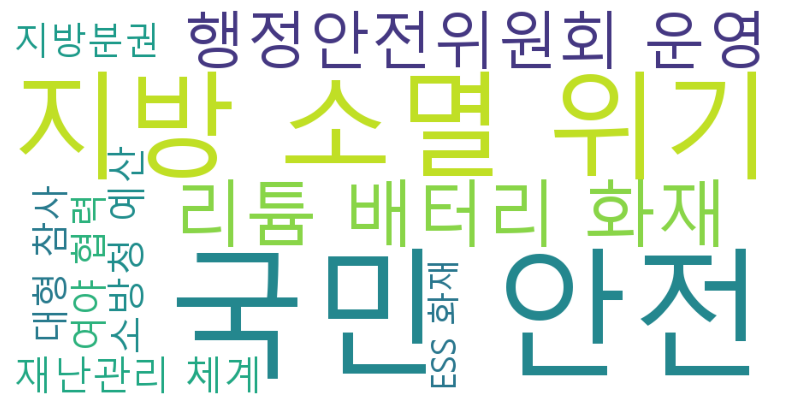

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import json

row = results[0]
freq = json.loads(row["키워드_가중치맵"])

wc = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white",
    width=900,
    height=450
).generate_from_frequencies(freq)

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis("off")
plt.show()

